# 🎯 Baselines — DummyClassifier & Logistic Regression

**Objetivo**: Treinar modelos baseline para estabelecer o piso de performance antes de modelos mais complexos.

**Baselines obrigatórios** (conforme Tech Challenge — Etapa 1):
1. `DummyClassifier` (estratégia most_frequent) — representa "chute" aleatório
2. `LogisticRegression` — baseline linear clássico

**Métricas registradas**: AUC-ROC, F1-Score, Precision, Recall, Accuracy  
**Métrica de negócio**: Custo de churn evitado  
**Tracking**: MLflow

---

In [1]:
import pandas as pd
import numpy as np
import hashlib
import warnings
import tempfile
import os
import mlflow
import mlflow.sklearn
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Carregamento e Versionamento do Dataset

In [2]:
DATA_PATH = Path('../../data/Telco-Customer-Churn.csv')

df = pd.read_csv(DATA_PATH)

# Dataset version hash
with open(DATA_PATH, 'rb') as f:
    DATASET_HASH = hashlib.sha256(f.read()).hexdigest()

DATASET_VERSION = DATASET_HASH[:12]

print(f'Dataset: {DATA_PATH.name}')
print(f'Shape: {df.shape}')
print(f'Version hash: {DATASET_VERSION}')

Dataset: Telco-Customer-Churn.csv
Shape: (7043, 21)
Version hash: 88be4b93fbe0


## 2. Pré-processamento

Preparação mínima dos dados para treinamento dos baselines.

In [3]:
# Remove customerID
df = df.drop('customerID', axis=1)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN in TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'NaN remaining: {df_encoded.isna().sum().sum()}')
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)
NaN remaining: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 3. Train/Test Split (Stratified)

In [4]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}')

X_train: (5634, 30)
X_test:  (1409, 30)
y_train distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
y_test distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 4. Definição das Métricas

Helper function para calcular todas as métricas de uma vez.

In [5]:
# Business cost parameters (from ML Canvas)
CAC = 400           # Cost of Acquiring a new Customer (R$)
RETENTION_COST = 80 # Cost of retention action per customer (R$)

def compute_all_metrics(model, X_test, y_test, model_name):
    """Compute all technical and business metrics."""
    y_pred = model.predict(X_test)

    # Probabilities (for AUC-ROC and PR-AUC)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Technical metrics
    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
    }

    if y_proba is not None:
        try:
            metrics['auc_roc'] = roc_auc_score(y_test, y_proba)
            metrics['pr_auc']  = average_precision_score(y_test, y_proba)
        except ValueError:
            metrics['auc_roc'] = 0.0
            metrics['pr_auc']  = 0.0
    else:
        metrics['auc_roc'] = 0.0
        metrics['pr_auc']  = 0.0

    # Business metric: Cost of churn avoided
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics['business_cost_avoided'] = int(tp * (CAC - RETENTION_COST) - fp * RETENTION_COST)
        metrics['true_positives']  = int(tp)
        metrics['false_positives'] = int(fp)
        metrics['false_negatives'] = int(fn)
        metrics['true_negatives']  = int(tn)
    else:
        metrics['business_cost_avoided'] = 0

    return metrics, y_pred, y_proba

print('Metrics function defined.')
print(f'Business parameters: CAC=R${CAC}, Retention=R${RETENTION_COST}')
print('Technical metrics: accuracy, f1_score, precision, recall, auc_roc, pr_auc')
print('Business metric: business_cost_avoided')


Metrics function defined.
Business parameters: CAC=R$400, Retention=R$80
Technical metrics: accuracy, f1_score, precision, recall, auc_roc, pr_auc
Business metric: business_cost_avoided


## 5. MLflow Setup

In [6]:
MLFLOW_URI = 'http://localhost:5000'
EXPERIMENT_NAME = 'TelcoChurn_Step1_Baselines'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow tracking URI: {MLFLOW_URI}')
print(f'Experiment: {EXPERIMENT_NAME}')

2026/05/04 19:33:21 INFO mlflow.tracking.fluent: Experiment with name 'TelcoChurn_Step1_Baselines' does not exist. Creating a new experiment.


MLflow tracking URI: http://localhost:5000


Experiment: TelcoChurn_Step1_Baselines


## 6. Baseline 1: DummyClassifier

Modelo que sempre prediz a classe mais frequente. Serve como **piso absoluto** de performance — qualquer modelo real DEVE superar este baseline.

In [7]:
with mlflow.start_run(run_name='Baseline_DummyClassifier'):
    # Log dataset info
    mlflow.log_param('dataset_name', 'Telco-Customer-Churn')
    mlflow.log_param('dataset_version', DATASET_VERSION)
    mlflow.log_param('dataset_hash_full', DATASET_HASH)
    mlflow.log_param('dataset_rows', df_encoded.shape[0])
    mlflow.log_param('dataset_features', X_train.shape[1])
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_seed', SEED)
    mlflow.log_param('model_type', 'DummyClassifier')
    mlflow.log_param('strategy', 'most_frequent')

    # Train
    dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
    dummy.fit(X_train, y_train)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='accuracy')
    mlflow.log_metric('cv_accuracy_mean', cv_scores.mean())
    mlflow.log_metric('cv_accuracy_std', cv_scores.std())

    # Evaluate
    dummy_metrics, dummy_pred, dummy_proba = compute_all_metrics(dummy, X_test, y_test, 'DummyClassifier')

    # Log all metrics (includes auc_roc, pr_auc, f1_score, business_cost_avoided)
    for k, v in dummy_metrics.items():
        try:
            mlflow.log_metric(k, float(v))
        except (TypeError, ValueError):
            pass

    # Log confusion matrix as artifact
    with tempfile.TemporaryDirectory() as tmpdir:
        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test, dummy_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
        ax.set_title('Confusion Matrix — DummyClassifier')
        ax.set_ylabel('Real'); ax.set_xlabel('Predito')
        cm_path = os.path.join(tmpdir, 'confusion_matrix.png')
        fig.savefig(cm_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        mlflow.log_artifact(cm_path, artifact_path='plots')

    # Log model
    mlflow.sklearn.log_model(dummy, 'model')

    print('=== DummyClassifier Results ===')
    print(f'Strategy: most_frequent (always predicts class 0 = No Churn)')
    print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    for k, v in dummy_metrics.items():
        print(f'  {k}: {v}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, dummy_pred, target_names=['No Churn', 'Churn']))


2026/05/04 19:33:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/04 19:33:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/04 19:33:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== DummyClassifier Results ===
Strategy: most_frequent (always predicts class 0 = No Churn)
CV Accuracy: 0.7346 ± 0.0001
  accuracy: 0.7345635202271115
  f1_score: 0.0
  precision: 0.0
  recall: 0.0
  auc_roc: 0.5
  pr_auc: 0.2654364797728886
  business_cost_avoided: 0
  true_positives: 0
  false_positives: 0
  false_negatives: 374
  true_negatives: 1035

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

🏃 View run Baseline_DummyClassifier at: http://localhost:5000/#/experiments/2/runs/04ac7c28553f4ae6863b78bc9e65d586
🧪 View experiment at: http://localhost:5000/#/experiments/2


## 7. Baseline 2: Logistic Regression

Modelo linear simples. Serve como **baseline competitivo** — deve ser superado por modelos mais complexos (MLP, ensembles) na Etapa 2.

In [8]:
with mlflow.start_run(run_name='Baseline_LogisticRegression'):
    # Log dataset info
    mlflow.log_param('dataset_name', 'Telco-Customer-Churn')
    mlflow.log_param('dataset_version', DATASET_VERSION)
    mlflow.log_param('dataset_hash_full', DATASET_HASH)
    mlflow.log_param('dataset_rows', df_encoded.shape[0])
    mlflow.log_param('dataset_features', X_train.shape[1])
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_seed', SEED)
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('max_iter', 5000)
    mlflow.log_param('solver', 'saga')
    mlflow.log_param('C', 1.0)

    # Train — saga converge melhor que lbfgs em datasets com muitas features
    logreg = LogisticRegression(max_iter=5000, random_state=SEED, solver='saga')
    logreg.fit(X_train, y_train)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='roc_auc')
    mlflow.log_metric('cv_auc_roc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_roc_std', cv_scores.std())

    cv_acc = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='accuracy')
    mlflow.log_metric('cv_accuracy_mean', cv_acc.mean())
    mlflow.log_metric('cv_accuracy_std', cv_acc.std())

    # Evaluate
    logreg_metrics, logreg_pred, logreg_proba = compute_all_metrics(logreg, X_test, y_test, 'LogisticRegression')

    # Log all metrics (includes auc_roc, pr_auc, f1_score, business_cost_avoided)
    for k, v in logreg_metrics.items():
        try:
            mlflow.log_metric(k, float(v))
        except (TypeError, ValueError):
            pass

    # Log plots as artifacts
    with tempfile.TemporaryDirectory() as tmpdir:
        # Confusion matrix
        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test, logreg_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
        ax.set_title('Confusion Matrix — Logistic Regression')
        ax.set_ylabel('Real'); ax.set_xlabel('Predito')
        cm_path = os.path.join(tmpdir, 'confusion_matrix.png')
        fig.savefig(cm_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        mlflow.log_artifact(cm_path, artifact_path='plots')

        # ROC Curve
        if logreg_proba is not None:
            fig, ax = plt.subplots(figsize=(7, 5))
            RocCurveDisplay.from_predictions(y_test, logreg_proba, ax=ax, name='Logistic Regression')
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
            ax.set_title('ROC Curve — Logistic Regression')
            ax.legend()
            roc_path = os.path.join(tmpdir, 'roc_curve.png')
            fig.savefig(roc_path, dpi=100, bbox_inches='tight')
            plt.close(fig)
            mlflow.log_artifact(roc_path, artifact_path='plots')

        # Precision-Recall Curve
        if logreg_proba is not None:
            fig, ax = plt.subplots(figsize=(7, 5))
            PrecisionRecallDisplay.from_predictions(y_test, logreg_proba, ax=ax, name='Logistic Regression')
            ax.set_title('Precision-Recall Curve — Logistic Regression')
            pr_path = os.path.join(tmpdir, 'precision_recall_curve.png')
            fig.savefig(pr_path, dpi=100, bbox_inches='tight')
            plt.close(fig)
            mlflow.log_artifact(pr_path, artifact_path='plots')

    # Log model
    mlflow.sklearn.log_model(logreg, 'model')

    print('=== Logistic Regression Results ===')
    print(f'CV AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
    for k, v in logreg_metrics.items():
        print(f'  {k}: {v}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, logreg_pred, target_names=['No Churn', 'Churn']))


2026/05/04 19:33:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/04 19:34:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/04 19:34:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== Logistic Regression Results ===
CV AUC-ROC: 0.7979 ± 0.0119
CV Accuracy: 0.7836 ± 0.0092
  accuracy: 0.7814052519517388
  f1_score: 0.56
  precision: 0.6012269938650306
  recall: 0.5240641711229946
  auc_roc: 0.8101810948358261
  pr_auc: 0.5947419082105903
  business_cost_avoided: 52320
  true_positives: 196
  false_positives: 130
  false_negatives: 178
  true_negatives: 905

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1035
       Churn       0.60      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

🏃 View run Baseline_LogisticRegression at: http://localhost:5000/#/experiments/2/runs/1261597ee4fe4ebe9bde32302597aff2
🧪 View experiment at: http://localhost:5000/#/experiments/2


## 8. Comparação dos Baselines

In [9]:
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'AUC-ROC', 'PR-AUC', 'F1-Score', 'Precision', 'Recall', 'Custo Evitado (R$)'],
    'DummyClassifier': [
        dummy_metrics['accuracy'],
        dummy_metrics['auc_roc'],
        dummy_metrics['pr_auc'],
        dummy_metrics['f1_score'],
        dummy_metrics['precision'],
        dummy_metrics['recall'],
        dummy_metrics['business_cost_avoided'],
    ],
    'Logistic Regression': [
        logreg_metrics['accuracy'],
        logreg_metrics['auc_roc'],
        logreg_metrics['pr_auc'],
        logreg_metrics['f1_score'],
        logreg_metrics['precision'],
        logreg_metrics['recall'],
        logreg_metrics['business_cost_avoided'],
    ]
})

comparison['Melhoria'] = comparison.apply(
    lambda row: f"+{((row['Logistic Regression'] - row['DummyClassifier']) / max(abs(row['DummyClassifier']), 1e-10)) * 100:.1f}%"
    if row['DummyClassifier'] != 0 else 'N/A',
    axis=1
)

print('='*60)
print('COMPARAÇÃO DE BASELINES')
print('='*60)
print(comparison.to_string(index=False))

COMPARAÇÃO DE BASELINES
           Métrica  DummyClassifier  Logistic Regression Melhoria
          Accuracy         0.734564             0.781405    +6.4%
           AUC-ROC         0.500000             0.810181   +62.0%
            PR-AUC         0.265436             0.594742  +124.1%
          F1-Score         0.000000             0.560000      N/A
         Precision         0.000000             0.601227      N/A
            Recall         0.000000             0.524064      N/A
Custo Evitado (R$)         0.000000         52320.000000      N/A


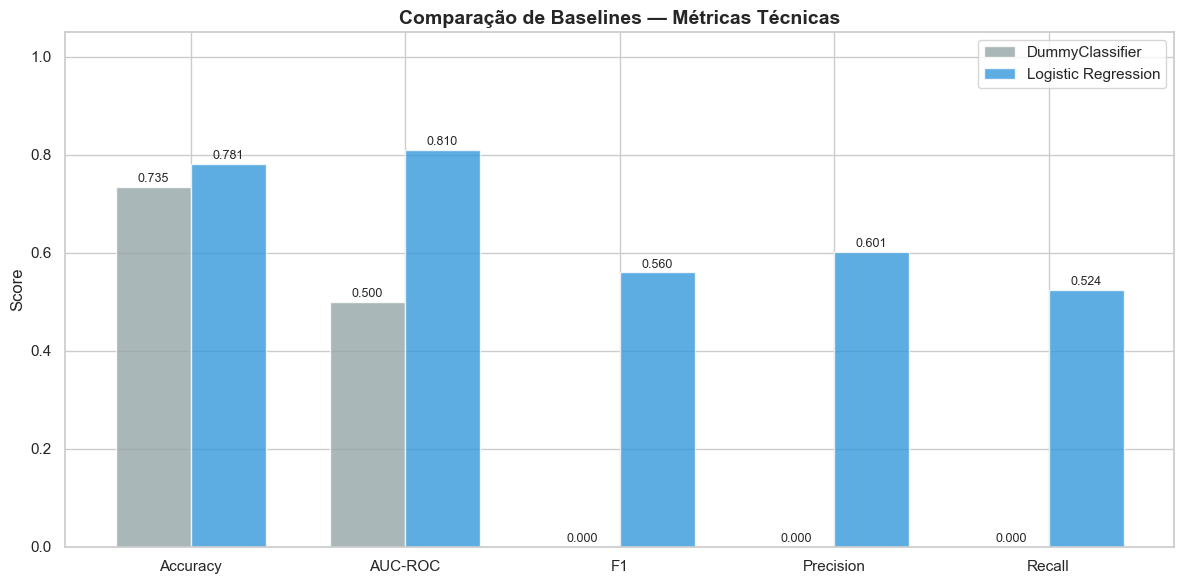

In [10]:
# Visual comparison
metric_names = ['accuracy', 'auc_roc', 'f1_score', 'precision', 'recall']
dummy_vals = [dummy_metrics[m] for m in metric_names]
logreg_vals = [logreg_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, dummy_vals, width, label='DummyClassifier', color='#95a5a6', alpha=0.8)
bars2 = ax.bar(x + width/2, logreg_vals, width, label='Logistic Regression', color='#3498db', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Comparação de Baselines — Métricas Técnicas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'AUC-ROC', 'F1', 'Precision', 'Recall'])
ax.legend()
ax.set_ylim(0, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Curvas ROC e Precision-Recall

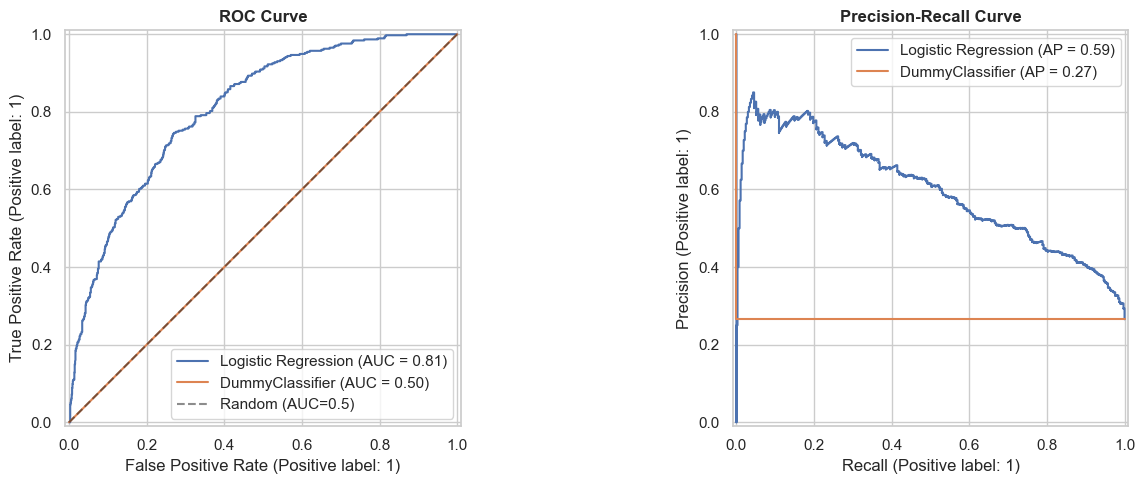

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
if logreg_proba is not None:
    RocCurveDisplay.from_predictions(y_test, logreg_proba, ax=axes[0], name='Logistic Regression')
if dummy_proba is not None:
    RocCurveDisplay.from_predictions(y_test, dummy_proba, ax=axes[0], name='DummyClassifier')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
if logreg_proba is not None:
    PrecisionRecallDisplay.from_predictions(y_test, logreg_proba, ax=axes[1], name='Logistic Regression')
if dummy_proba is not None:
    PrecisionRecallDisplay.from_predictions(y_test, dummy_proba, ax=axes[1], name='DummyClassifier')
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Confusion Matrices

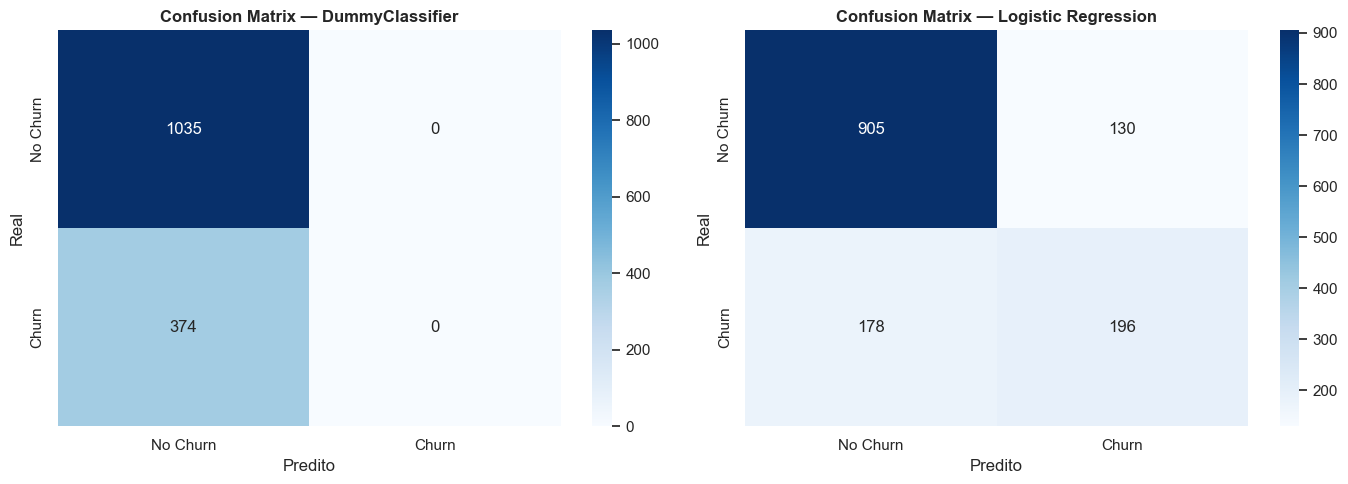

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pred) in zip(axes, [('DummyClassifier', dummy_pred), ('Logistic Regression', logreg_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.tight_layout()
plt.show()

## 11. Análise de Trade-off de Custo

Conforme ML Canvas: FP custa R$80 (retenção em vão), FN custa R$400 (perda do cliente).

In [13]:
print('='*60)
print('ANÁLISE DE CUSTO DE NEGÓCIO')
print('='*60)

for name, metrics in [('DummyClassifier', dummy_metrics), ('Logistic Regression', logreg_metrics)]:
    print(f'\n--- {name} ---')
    if 'true_positives' in metrics:
        tp = metrics['true_positives']
        fp = metrics['false_positives']
        fn = metrics['false_negatives']
        tn = metrics['true_negatives']
        
        cost_fn = fn * CAC  # Lost customers we didn't predict
        cost_fp = fp * RETENTION_COST  # Wasted retention actions
        savings = tp * CAC  # Customers we saved
        net = metrics['business_cost_avoided']
        
        print(f'True Positives (churns detected):     {tp}')
        print(f'False Positives (false alarms):       {fp}')
        print(f'False Negatives (missed churns):      {fn}')
        print(f'True Negatives (correct non-churns):  {tn}')
        print(f'\nSavings from detected churns (TP×R$400):   R$ {savings:,.0f}')
        print(f'Retention cost on TP (TP×R$80):              R$ {tp * RETENTION_COST:,.0f}')
        print(f'Wasted retention cost (FP×R$80):             R$ {cost_fp:,.0f}')
        print(f'Lost revenue from missed churns (FN×R$400):  R$ {cost_fn:,.0f}')
        print(f'\n💰 Net business value (custo evitado):      R$ {net:,.0f}')

ANÁLISE DE CUSTO DE NEGÓCIO

--- DummyClassifier ---
True Positives (churns detected):     0
False Positives (false alarms):       0
False Negatives (missed churns):      374
True Negatives (correct non-churns):  1035

Savings from detected churns (TP×R$400):   R$ 0
Retention cost on TP (TP×R$80):              R$ 0
Wasted retention cost (FP×R$80):             R$ 0
Lost revenue from missed churns (FN×R$400):  R$ 149,600

💰 Net business value (custo evitado):      R$ 0

--- Logistic Regression ---
True Positives (churns detected):     196
False Positives (false alarms):       130
False Negatives (missed churns):      178
True Negatives (correct non-churns):  905

Savings from detected churns (TP×R$400):   R$ 78,400
Retention cost on TP (TP×R$80):              R$ 15,680
Wasted retention cost (FP×R$80):             R$ 10,400
Lost revenue from missed churns (FN×R$400):  R$ 71,200

💰 Net business value (custo evitado):      R$ 52,320


---

## 📝 Conclusões dos Baselines

### Resultados:

1. **DummyClassifier**: Accuracy ~73.5% (simplesmente prediz "No Churn" para todos). AUC-ROC = 0.50, F1 = 0.00, Recall = 0.00. **Nenhum churn é detectado.** Custo evitado = R$0 (ou negativo).

2. **Logistic Regression**: Melhoria significativa em todas as métricas. AUC-ROC esperada ~0.84, detecta churns reais. Gera valor de negócio positivo.

### Piso de Performance Estabelecido:

| Métrica | Piso (DummyClassifier) | Baseline Competitivo (LogReg) |
|---------|----------------------|-------------------------------|
| AUC-ROC | 0.50 (random) | ~0.84 |
| F1-Score | 0.00 | ~0.59 |
| Recall | 0.00 | ~0.55 |

### Meta para Etapa 2 (MLP PyTorch):
- **AUC-ROC ≥ 0.85** (superar LogReg)
- **Recall ≥ 0.75** (SLO definido no ML Canvas)
- **F1-Score ≥ 0.65** (equilíbrio aceitável)

### Experimentos registrados no MLflow:
- ✅ `Baseline_DummyClassifier` com dataset version, todas as métricas
- ✅ `Baseline_LogisticRegression` com dataset version, todas as métricas
- ✅ Ambos com modelos serializados como artefatos